In [82]:
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUseRejectionSampling, AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel,EQIntegralKernel
import numpy as np
import matplotlib.pyplot as plt
from jax.random import normal
import jax
from jax.random import multivariate_normal as mvn
from BLEanalysis.angleinference import AnglesUsePatternMeans, normalise_logs_to_ps

Load the file we want to infer a path from,

In [83]:
testdata = Signals("../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log",['c','a','b','e'],filetype='log',angleOffset=0)
GPSfilepath = "../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv"

# For evaluating the GPS path pointwise against the inferred path, we want to infer a path across the times that we've tracked with GPS
startingTime = 5
endingTime = 28

Standardising angles and times (shifting by 0.00 degrees)


Define hyperparameters (keep the same across all tests):

In [84]:
ls = 3 # Kernel length scale
scale = 13 # Kernel scale factor
nInd = 20 # Number of inducing points
noise = 0.5 # Noise scale
timeScale = 10000 # Scale time series down by this factor when preparing observations

nSamps = 200 # Max number of samples to use per burst for path reconstruction
            # (2 second bursts, how many samples within that burst)
burstLength = 2000 # in ms
samplingMethod = "linspaceIdxs" # random, linspaceTimes, linspaceIdxs

k = ExponentiatedQuadraticKernel(ls,scale)
#k = EQIntegralKernel(2,5)

Define the transmitter IDs, locations and times,

Transmitter       Number of records
        a                 8467
        b                 3744
        c                14636
        e                 7515


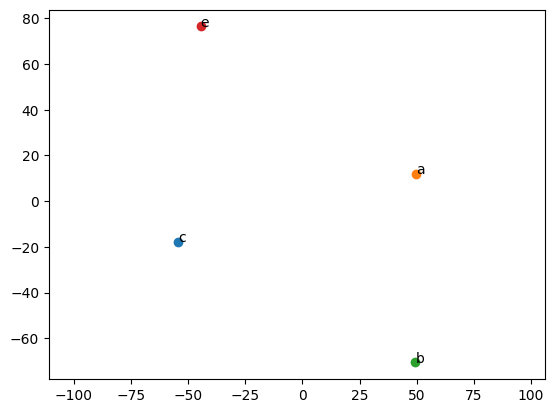

In [85]:
testdata.configureTransmitter('c',0,0,transmitterLat = 53.368359, transmitterLon = -1.450168)
testdata.configureTransmitter('a',-(167340+194210),0,transmitterLat = 53.368606, transmitterLon = -1.448596)
testdata.configureTransmitter('b',-(167340+194210+121110),0,transmitterLat = 53.367865, transmitterLon = -1.448626)
testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# Normalise the transmitter locations around zero, in preparation for the observations
testdata.noramliseTransmitterLocs()
testdata.summarise(showNormalised = True)

# Using peak signal strength heuristic

Prepare observations,

In [69]:
obs = []
obstimes = []

# Get packet bursts from data
burst, time = testdata.parseBursts(burstInterval=0)
angles = AnglesUsePeaks(5)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    prediction = angles.infer(burst[b]['rssis'], burst[b]['angles'])
    # If a peak was found
    if not (np.isnan(prediction)):
        # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
        obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
        # Add time of observation
        obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


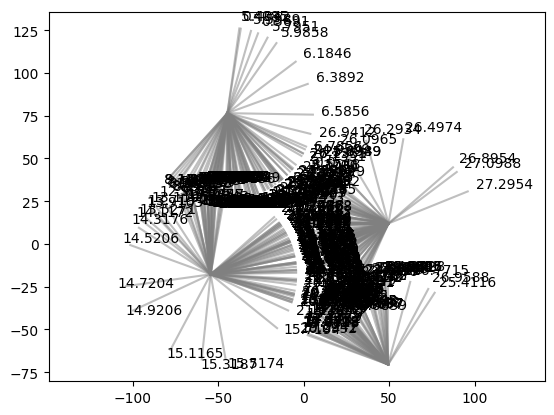

In [70]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

Perform inference,

In [71]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * 0.2, jitter = 0.01)
path.run(200,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0: 1594816.8
iteration   50:  302920.2
iteration  100:  182066.3
iteration  150:  175610.1
Optimising mean and covariance...
iteration    0:  167733.2
iteration   50:  140676.2
iteration  100:  143196.5
iteration  150:  135977.4


Text(0.5, 1.0, 'Path Inferred from Vectors (Peak RSSI)')

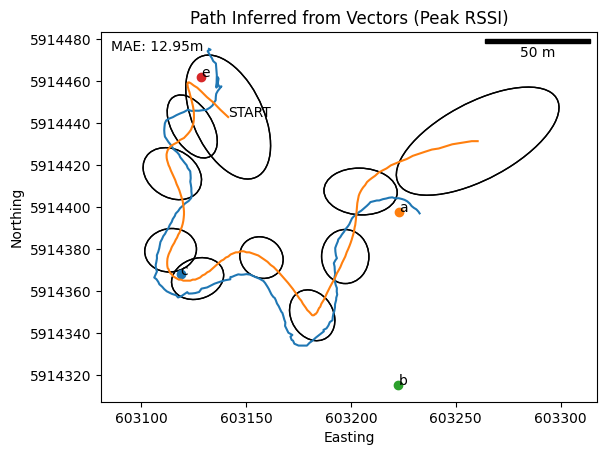

In [72]:
path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

plt.title("Path Inferred from Vectors (Peak RSSI)")

# Using rejection sampling

In [19]:
rejectionSampling = AnglesUseRejectionSampling(rejectionTableStep = 50)

Standardising angles and times (shifting by 38.00 degrees)
100000ms out of 733482ms added to table.
150000ms out of 733482ms added to table.
200000ms out of 733482ms added to table.
250000ms out of 733482ms added to table.
300000ms out of 733482ms added to table.
350000ms out of 733482ms added to table.
400000ms out of 733482ms added to table.
450000ms out of 733482ms added to table.
500000ms out of 733482ms added to table.
550000ms out of 733482ms added to table.
600000ms out of 733482ms added to table.
650000ms out of 733482ms added to table.
700000ms out of 733482ms added to table.
Rejection table built of 733482ms of antenna profile.


In [20]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    predictions = rejectionSampling.inferFromBurst(burst[b],filter=True,filterMean = 5, filterStd = 0.5)
    for prediction in predictions: 
        if not (np.isnan(prediction[1])):
            # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction[1]), np.cos(prediction[1])])
            # Add time of observation
            obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:214: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


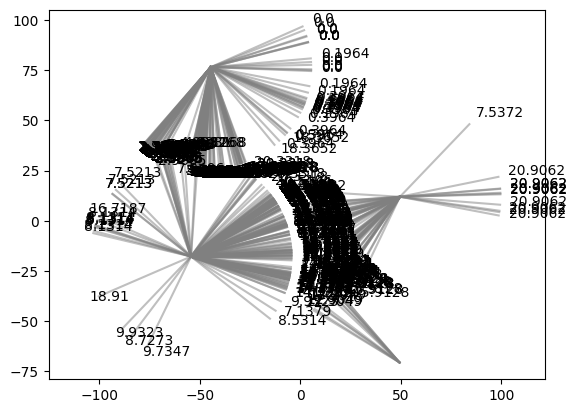

In [21]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

In [22]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * 0.2, jitter = 1)
path.run(200,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0: 2627119.2
iteration   50:  238750.8
iteration  100:   65640.6
iteration  150:   55460.1
Optimising mean and covariance...
iteration    0:   64654.7
iteration   50:   34687.2
iteration  100:   33534.5
iteration  150:   33228.5


Text(0.5, 1.0, 'Path Inferred from Vectors (Rejection Sampling)')

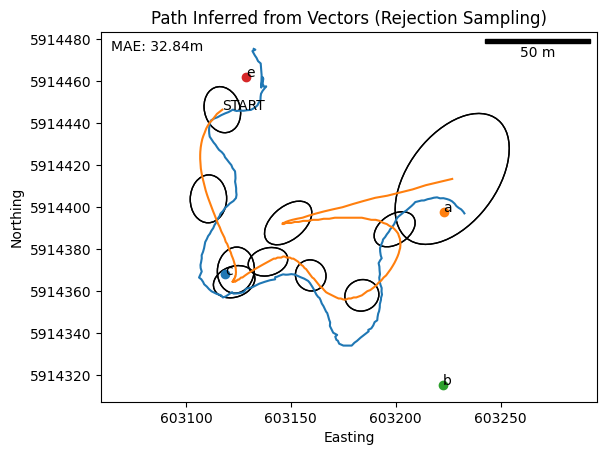

In [27]:
path.plot(startTime = startingTime-3, endTime = endingTime-6, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

plt.title("Path Inferred from Vectors (Rejection Sampling)")

# Using probability distribution

In [76]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=6**2)
for b in range(len(burst)):
    newburst = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    obstimes.append(time[b])
    obs.append(newburst)

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

Standardising angles and times (shifting by 38.00 degrees)


In [78]:
# NOISE SCALE, INDUCING POINTS TODO : standardize order

path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,noise,nInd, margin = np.max(obstimes) * 0.2, jitter = 0.1)

path.run(300,learning_rate=0.5, just_optimise_means = False)

Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0: 2144736.8
iteration   50: 1557107.2
iteration  100: 1211575.4
iteration  150: 1019754.2
iteration  200:  957437.5
iteration  250:  955359.8
Optimising mean and covariance...
iteration    0:  948727.8
iteration   50:  827837.1
iteration  100:  782141.9
iteration  150:  765889.3
iteration  200:  758096.2
iteration  250:  748786.8


Text(0.5, 1.0, 'Path Inferred from Probability Distributions')

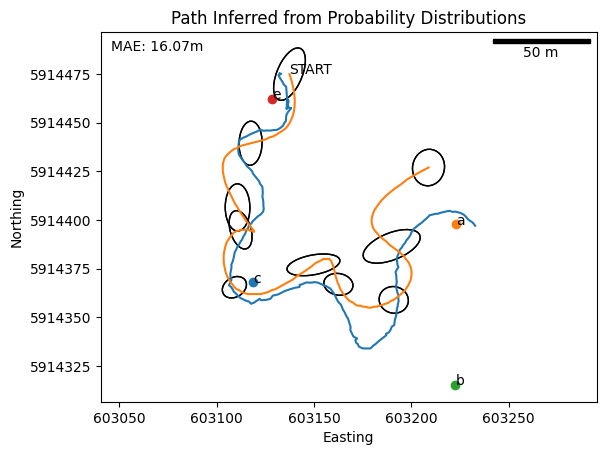

In [81]:
path.plot(startTime = startingTime+1, endTime = endingTime-2, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)
plt.title("Path Inferred from Probability Distributions")

# Using vectors sampled from probability distribution

In [93]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=6**2)
import scipy



# Use the yamartino method to get the variance of a circular pdf, filter based on variance
def yamartino(thetalist):
    s=0
    c=0
    n=0.0
    for theta in thetalist:
        s=s+np.sin(np.deg2rad(theta))
        c=c+np.cos(np.deg2rad(theta))
        n+=1
    s=s/n
    c=c/n
    eps=(1-(s**2+c**2))**0.5
    sigma=np.arcsin(eps)*(1+(2.0/3.0**0.5-1)*eps**3)
    return np.rad2deg(sigma)
    
for b in range(len(burst)):
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
    ps = normalise_logs_to_ps(logps)
    prediction = np.argmax(ps)
    if not (np.isnan(prediction)):
        if yamartino(logps) >50:
            prediction = np.deg2rad(prediction)
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
            obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale


Standardising angles and times (shifting by 38.00 degrees)


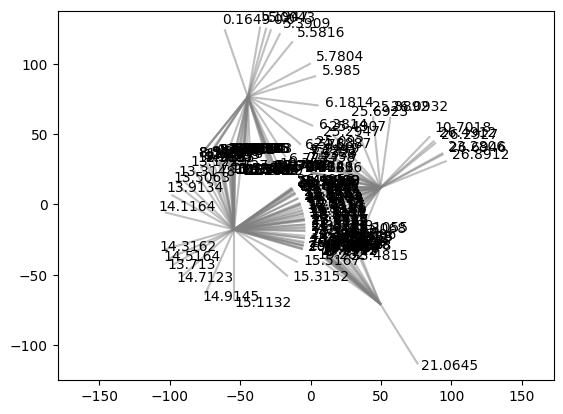

In [94]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

In [88]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,20,noise, margin = np.max(obstimes) * 0.2, jitter = 0.01)
path.run(200,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0:  822159.4
iteration   50:   99294.4
iteration  100:   50797.5
iteration  150:   45877.1
Optimising mean and covariance...
iteration    0:   36447.0
iteration   50:   26882.3
iteration  100:   23931.2
iteration  150:   50083.5


Text(0.5, 1.0, 'Path Inferred from Vectors (Peak RSSI)')

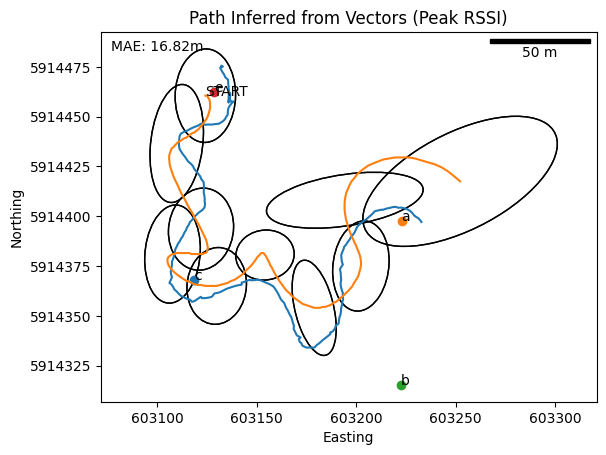

In [90]:
path.plot(startTime = startingTime+1, endTime = endingTime-1, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

plt.title("Path Inferred from Vectors (Peak RSSI)")